# Exercise 1: The Driven Pendulum

In [59]:
import scipy.integrate
import numpy as np
import matplotlib.pyplot as plt

# <b> Core task 1: </b> Integrating the equation

In [60]:
# Define variables and initial conditions
g = l = 1
q = 0
F = 0
driving_freq = 2/3
T0 = 2*np.pi # Natural oscillation frequency

In [61]:
def pend_deriv(t, y, q, F):
    """Function returning derivatives of y = [y0, y1] = [angle, angular velocity] at a given time t, 
    with additional parameters q, F to account for damping and driving force"""
    y0, y1 = y
    dy0 = y1
    dy1 = -g/l * np.sin(y0) - q*y1 + F*np.sin(driving_freq*t)
    return [dy0, dy1]

In [62]:
# Define function for integrating the solution for certain parameters (for ease)
def pend_solution(start, end, dt, amplitude, q=0, F=0):
    """Function takes as input the total timespan for integration, the time interval dt, initial amplitude, and parameters as a tuple (q,F).
    Outputs solution as object where .t gets the time coords, .y[0] the angular coords, .y[1] the angular velocity coords"""
    solution = scipy.integrate.solve_ivp(
        fun=pend_deriv,
        t_span=(start, end),
        y0=(amplitude, 0),
        t_eval = np.arange(start, end, dt),
        args=(q, F)
    )
    return solution

## Testing and plotting the solutions

Set q = F = 0, initial amplitude = 0.01, plotting solutions for 10, 100, 1000 natural periods; plot 10 periods for each against the theoretical solution which is just a cosine

In [63]:
def plot_undamped_periods(N):
    """Plot the solutions under the conditions specified above at the Nth natural periods"""
    solution = pend_solution((N-10)*T0, N*T0, dt=0.1, amplitude=0.01, q=0, F=0)
    plt.plot(solution.t, solution.y[0], label="numerical")
    plt.plot(solution.t, 0.01*np.cos(solution.t), label="analytical")
    plt.xlabel("Time/s")
    plt.ylabel("Angle/rad")
    plt.title("Angle vs time for an undamped pendulum")
    plt.legend();

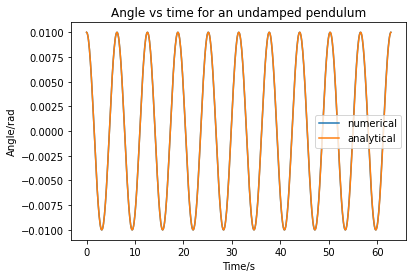

In [64]:
plot_undamped_periods(10)

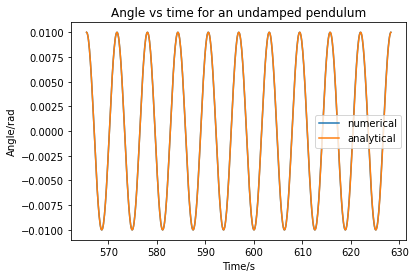

In [65]:
plot_undamped_periods(100)

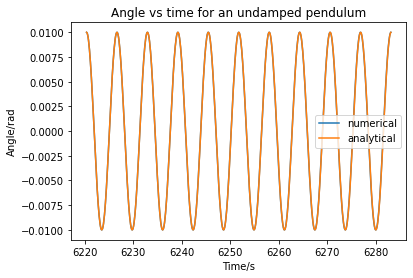

In [66]:
plot_undamped_periods(1000)

As expected, the theoretical and numerical solutions agree very well

## Testing conservation of energy over time

In [67]:
ten_thousand = pend_solution(0, 10_000*T0, dt=0.1, amplitude=0.01, q=0, F=0)

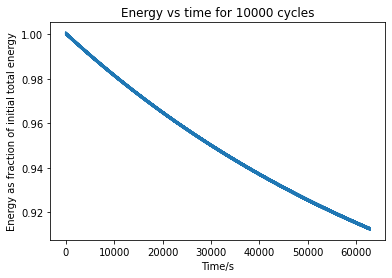

In [68]:
# Testing conservation of energy over time; y[1] is angular velocity, y[0] angle
total_energy = 0.5*(l**2)*(ten_thousand.y[1]**2) + g*l*(1-np.cos(ten_thousand.y[0])) 
total_energy = total_energy/total_energy[0]

plt.plot(ten_thousand.t, total_energy)
plt.xlabel("Time/s")
plt.ylabel("Energy as fraction of initial total energy")
plt.title("Energy vs time for 10000 cycles");

The system seems to monotonically decrease in energy, losing around 8% of its original energy over 10,000 cycles. The integrator might be sufficient for modelling short time periods, but over longer times a symplectic integrator e.g. Verlet would be better suited to explicitly conserving energy.

## Finding how amplitude affects the period of oscillation

In [69]:
def period(omega, t):
    """
    Returns the time period of an angular velocity solution (t are the 
    corresponding points in time) by finding the time between every second zero - use angular velocity
    instead of angle to avoid problems with wrap-around
    """
    return t[1:][omega[1:] * omega[:-1] <= 0][2]

In [70]:
t_end = 4*T0 # Solve for four natural periods
angles = np.linspace(0, np.pi, 100)[1:] # remove zero amplitude
periods = [] # list of periods
failed = False

for angle in angles:
    # Loop through all initial angles, perform integration for each angle, find period and append to a list
    solution = pend_solution(0, 4*T0, dt=0.05, amplitude=angle, q=0, F=0)
    t = solution.t
    omega = solution.y[1]
    # Some solutions are difficult for the integrator (when initial angle is nearly vertical); flag these up
    try:
        angle_period = period(omega, t)
        if not failed:
            periods.append(angle_period)
    except:
        failed = True
        print(f"{angle} went wrong")

3.0463928762082846 went wrong
3.078126135335454 went wrong
3.1098593944626236 went wrong


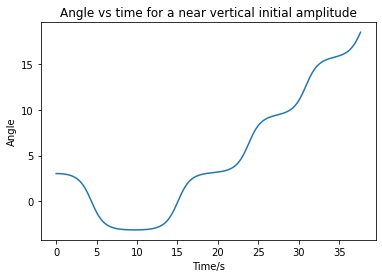

In [71]:
# Scrutinize these points further
disaster = pend_solution(0, 6*T0, dt=0.05, amplitude=3.04, q=0, F=0)
plt.plot(disaster.t, disaster.y[0])
plt.title("Angle vs time for a near vertical initial amplitude")
plt.xlabel("Time/s")
plt.ylabel("Angle");

As can be seen, the angle 'wraps around' for initial amplitudes too close to vertical, which means the pendulum no longer has a period in the previous sense, of oscillations with turning points about a fixed centre. Of course, by conservation of energy the angle should not wrap around - this is a problem with the integrator, which is not accurate enough with the chosen precision of dt=0.05.

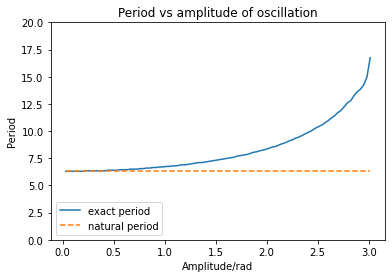

In [72]:
# Plotting period vs amplitude of oscillation
angles = angles[:len(periods)] # remove ill-behaved angles
plt.plot(angles, periods, label="exact period")
plt.plot(angles, np.ones(len(angles))*T0, linestyle="--", label="natural period")
plt.ylim(0,20)
plt.legend(loc="lower left")
plt.title("Period vs amplitude of oscillation")
plt.xlabel("Amplitude/rad")
plt.ylabel("Period");

In [73]:
# Printing the period at amplitude pi/2
solution_halfpi = pend_solution(0, t_end, dt=0.05, amplitude=0.5*np.pi, q=0, F=0)
theta_halfpi, omega_halfpi = solution_halfpi.y[0], solution_halfpi.y[1]
period_halfpi = period(omega_halfpi, solution_halfpi.t)
print(f"The period at initial amplitude = pi/2 is {period_halfpi}s")

The period at initial amplitude = pi/2 is 7.45s


### Conclusion
Numerical integration of the equation using scipy.integrate.solve_ivp was shown to give solutions that agreed well with theory. Energy was not conserved over a longer period of 10,000 natural oscillations, losing a fraction of 8%, but this suffices over short time ranges. 
Solving for initial angles from 0 to pi revealed that the period of oscillation monotonically increased from the natural period, up to the angles where the solutions were still well-behaved at the sampling time interval (dt=0.05) chosen. This is a result that is not easily seen analytically - shows why numerical methods can be useful. 

In [74]:
# # Animating the solution for a specific amplitude
# import matplotlib.animation as animation

# theta = disaster.y[0]
# x = np.sin(theta)[::5]
# y = -np.cos(theta)[::5]

# fig = plt.figure()
# ax = fig.add_subplot(111, autoscale_on=False, xlim=(-2, 2), ylim=(-2, 2))
# ax.grid()
# ax.set_aspect("equal")

# line, = ax.plot([], [], 'o-', lw=2)

# def init():
#     line.set_data([], [])
#     return line,


# def animate(i):
#     thisx = [0, x[i]]
#     thisy = [0, y[i]]
#     line.set_data(thisx, thisy)
#     return line,

# ani = animation.FuncAnimation(fig, animate, np.arange(1, len(y)),
#                               interval=25, blit=True, init_func=init)

# ani.save('pendulum.mp4', fps=15)

# <b> Core task 2: </b> Adding damping

In [75]:
def period_d(omega, t):
    """
    Returns period of angular velocity solution after several oscillations i.e. 
    once the behaviour has become regular ("damped period")
    """
    zeroes = t[1:][omega[1:] * omega[:-1] <= 0]
    return zeroes[7]-zeroes[5]

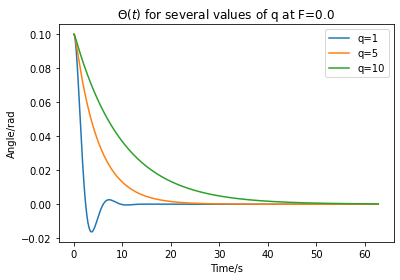

In [76]:
# Solving and plotting solutions where q = 1, 5, 10
q_values = [1, 5, 10]

for q_ in q_values:
    damped_solution = pend_solution(0, 10*T0, dt=0.1, amplitude=0.1, q=q_, F=0)
    t, theta = damped_solution.t, damped_solution.y[0]
    plt.plot(t, theta, label=f"q={q_}")

plt.xlabel("Time/s")
plt.ylabel("Angle/rad")
plt.title("$\Theta(t)$ for several values of q at F=0.0")
plt.legend();

Pendulum appears underdamped at q=1, near critical damping at q=5, and overdamped at q=10, which is as expected from increasing the amount of damping q. 

In [89]:
F_values = [0.5, 1.2, 1.33, 1.465]
# Create dictionary of solutions for ease of plotting
theta_solutions = {}
omega_solutions = {}

for F_ in F_values:
    driven_solution = pend_solution(0, 10*T0, dt=0.1, amplitude=0.1, q=0.5, F=F_)
    theta, omega = driven_solution.y[0], driven_solution.y[1]
    theta_solutions[str(F_)] = theta
    omega_solutions[str(F_)] = omega
    t_damped = driven_solution.t

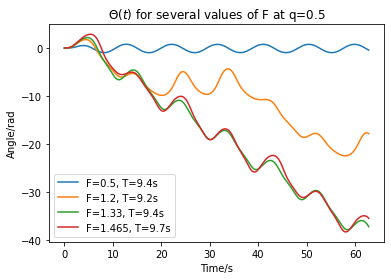

In [78]:
# Plotting angle for the different values of F
for F, theta in theta_solutions.items():
    this_period = period_d(omega_solutions[F], t_damped)
    plt.plot(t_damped, theta, label=f"F={F}, T={this_period:.1f}s")
    
plt.xlabel("Time/s")
plt.ylabel("Angle/rad")
plt.title("$\Theta(t)$ for several values of F at q=0.5")
plt.legend();

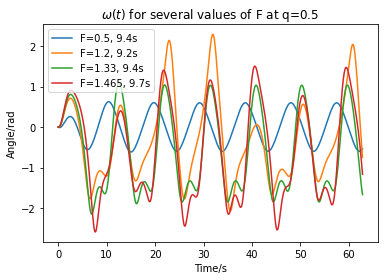

In [79]:
# Plotting angular velocity for the different values of F
for F, omega in omega_solutions.items():
    this_period = period_d(omega, t_damped)
    plt.plot(t_damped, omega, label=f"F={F}, {this_period:.1f}s")

plt.xlabel("Time/s")
plt.ylabel("Angle/rad")
plt.title("$\omega(t)$ for several values of F at q=0.5")
plt.legend();

The solutions have an approximate period of 9.4 seconds, which is expected - this is the period corresponding to the driving frequency of 2/3 rad s^-1. The motion is not quite periodic at higher driving forces, with sudden deviations at F=1.2, suggesting the system may become chaotic. 

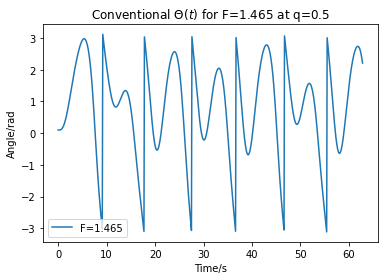

In [80]:
# Plotting again while keeping 0 < theta < 2pi, for F=1.465
thisF = F_values[3]
solution = theta_solutions[str(thisF)]

# Updating the angles in the array so that -pi < theta < pi
solution %= 2*np.pi
solution = np.where((solution>np.pi), solution-2*np.pi, solution)

plt.plot(t_damped, solution, label=f"F={thisF}")
plt.xlabel("Time/s")
plt.ylabel("Angle/rad")
plt.title(f"Conventional $\Theta(t)$ for F={thisF} at q=0.5")
plt.legend();

In [81]:
# # Animating the solution for a specific amplitude
# import matplotlib.animation as animation

# theta = solution
# theta = theta % (2*np.pi)
# step = 3

# x = np.sin(theta)[::step]
# y = -np.cos(theta)[::step]

# fig = plt.figure()
# ax = fig.add_subplot(111, autoscale_on=False, xlim=(-2, 2), ylim=(-2, 2))
# ax.grid()
# ax.set_aspect("equal")

# line, = ax.plot([], [], 'o-', lw=2)
# time_template = 'time = %.1fs'
# time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)

# def init():
#     line.set_data([], [])
#     time_text.set_text('')
#     return line, time_text


# def animate(i):
#     thisx = [0, x[i]]
#     thisy = [0, y[i]]
#     line.set_data(thisx, thisy)
#     time_text.set_text(time_template % (step*i*dt))
#     return line, time_text

# ani = animation.FuncAnimation(fig, animate, np.arange(1, len(y)),
#                               interval=100, blit=True, init_func=init)

# ani.save('pendulum1.mp4', fps=15)

# <b> Supplementary task 1 </b>: Sensitivity to initial conditions

In [82]:
# Find two solutions with slightly differing initial amplitudes
sensitive_solution1 = pend_solution(0, 100*T0, dt=0.1, amplitude=0.2, q=0.5, F=1.2)
t_sensitive, theta1, omega1 = sensitive_solution1.t, sensitive_solution1.y[0], sensitive_solution1.y[1]

sensitive_solution2 = pend_solution(0, 100*T0, dt=0.1, amplitude=0.20001, q=0.5, F=1.2)
theta2, omega2 = sensitive_solution2.y[0], sensitive_solution2.y[1]


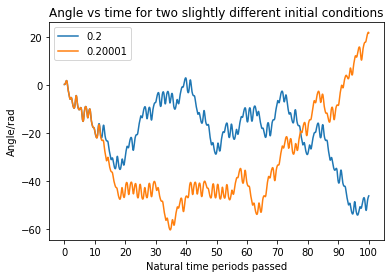

In [83]:
plt.plot(t_sensitive, theta1, label="0.2")
plt.plot(t_sensitive, theta2, label="0.20001")
plt.title("Angle vs time for two slightly different initial conditions")
plt.ylabel("Angle/rad")
plt.xlabel("Natural time periods passed")
plt.xticks(np.linspace(0, 100*T0, 11), np.linspace(0, 100, 11).astype(int))
plt.legend();

The solutions diverge quickly; significant difference observed by around 20 periods, suggests the driven/damped system is very sensitive to initial conditions/chaotic.

# <b> Supplementary task 2 </b>: Angle vs angular speed

In [84]:
class Pendulum:
    def __init__(self, q, F, start=0, end=50*T0, dt=0.02, amplitude=0.2):
        self.q = q
        self.F = F
        solution = pend_solution(start, end, dt, amplitude, q, F)
        self.theta, self.omega = solution.y[0], solution.y[1]
        self.theta %= 2*np.pi
        self.theta = np.where((self.theta>np.pi), self.theta-2*np.pi, self.theta)

In [85]:
chaos_plots1 = {}
for i in [0.1, 0.3, 0.4, 2, 10, 100]:
    chaos_plots1[str(i)] = Pendulum(q=0, F=i)

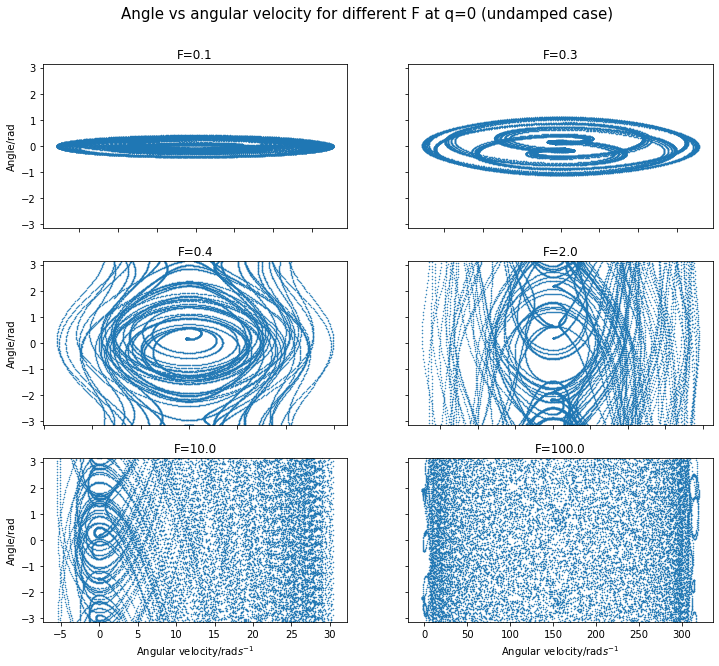

In [86]:
# Plot in phase space for different values of F when q=0
fig, axs = plt.subplots(3,2, figsize=(12,10))
chaos_F1 = [*chaos_plots1]
for F, ax in zip(chaos_F1, axs.flatten()):
    plot = chaos_plots1[F]
    ax.plot(plot.omega, plot.theta, 'o', ms=0.5)
    ax.label_outer()
    ax.set_ylim(-np.pi, np.pi)
    ax.set_title(f"F={float(F):.1f}")

axs[0,0].set_ylabel('Angle/rad')
axs[1,0].set_ylabel('Angle/rad')
axs[2,0].set_ylabel('Angle/rad')
axs[2,0].set_xlabel('Angular velocity/rad$s^{-1}$')
axs[2,1].set_xlabel('Angular velocity/rad$s^{-1}$')
fig.suptitle('Angle vs angular velocity for different F at q=0 (undamped case)', fontsize=15)
fig.subplots_adjust(top=0.9)
fig.tight_layout;

The behaviour of the undamped case seems to be split into two regimes. When F is below ~0.4, the motion is periodic, as seen from the closed elliptical orbits in phase space. 

Above this, motion becomes chaotic - the orbit is no longer closed, with the points in phase space becoming increasingly homogeneous. Some periodic, pseudoelliptical orbits are still seen centred around zero, suggesting alternating intervals of more and less chaotic motion.

At very high F, the mass is effectively subject to a random force, causing a roughly uniform distribution of point in phase space

Repeat for damped case; only the ratio F/q matters, so without loss of generality set q=1 and vary F

In [87]:
chaos_plots2 = {}
for i in [0.5, 3, 5, 10, 20, 100]:
    chaos_plots2[str(i)] = Pendulum(q=1, F=i)

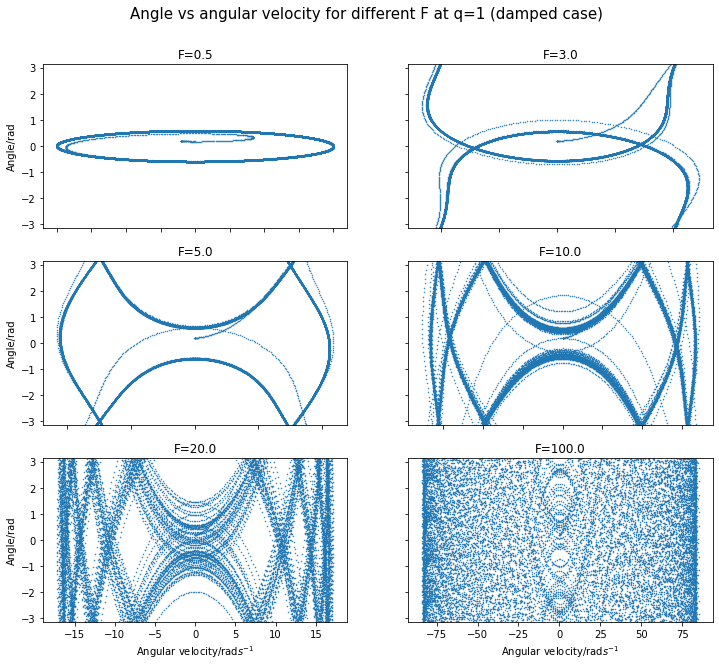

In [88]:
# Plot in phase space for different values of F when q=1
fig, axs = plt.subplots(3,2, figsize=(12,10))
chaos_F2 = [*chaos_plots2]
for F, ax in zip(chaos_F2, axs.flatten()):
    plot = chaos_plots2[F]
    ax.plot(plot.omega, plot.theta, 'o', ms=0.5)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_title(f"F={float(F):.1f}")
    ax.label_outer()

axs[0,0].set_ylabel('Angle/rad')
axs[1,0].set_ylabel('Angle/rad')
axs[2,0].set_ylabel('Angle/rad')
axs[2,0].set_xlabel('Angular velocity/rad$s^{-1}$')
axs[2,1].set_xlabel('Angular velocity/rad$s^{-1}$')
fig.suptitle('Angle vs angular velocity for different F at q=1 (damped case)', fontsize=15)
fig.subplots_adjust(top=0.9)
fig.tight_layout;

The orbits are closed/periodic for much larger values of F. The pendulum has a single period up to around F=5, a double loop at around F=5, then increasing numbers of loops as F increases further (as can be seen for F=10). At very high values of F, the number of periodic loops increases to a point where the motion is effectively chaotic, and looks uniform in phase space (F=100). 